## Define the Business Problem

### we are using diffrent tree models to find wether the person is high risk or low risk 



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("../data/raw/LoanPrediction.csv")
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [ ]:
df.shape

(252000, 13)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB


In [6]:
df_clean = df.drop(columns=["Id"])
df_clean.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [7]:
df_clean['Risk_Flag'].value_counts()   

Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

In [8]:
# describe the data
df_clean[['Income','Age','Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS']].describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000


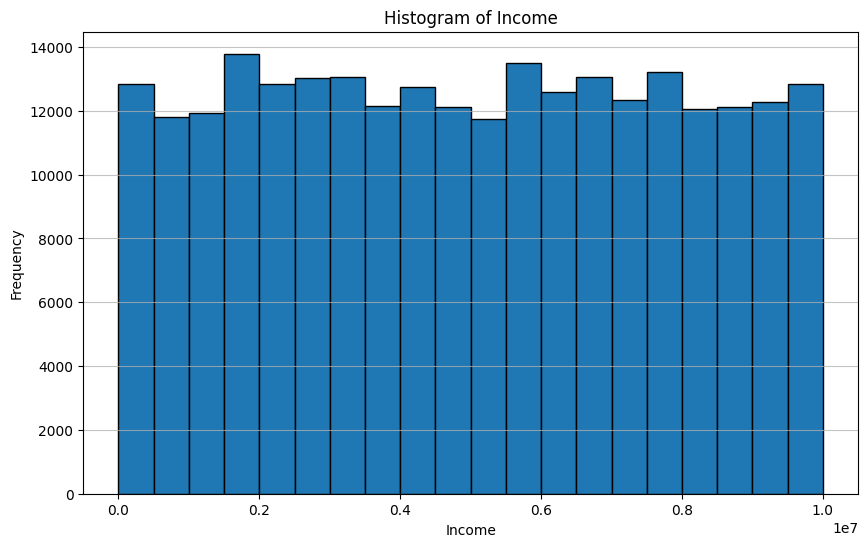

In [ ]:

column_name = 'Income'
plt.figure(figsize=(10, 6))
plt.hist(df_clean[column_name], bins=20, edgecolor='black')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.title(f'Histogram of {column_name}')
plt.grid(axis='y', alpha=0.75)
plt.show()

## spliting the x and y

In [9]:
X = df_clean.drop(columns=['Risk_Flag'])
y = df_clean['Risk_Flag']

## ✅ Step 1 — Train / Test split

### You need this first. Keep it simple.

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42,stratify=y)

print(X_train.shape, X_test.shape)

(176400, 11) (75600, 11)


## ✅ Step 2 — Handle categorical columns (very important)

### Your dataset has many object columns. Tree models in sklearn need numeric data.

### Use Label Encoding for now. Fast and practical.

In [11]:
# encode the categorical variables is for tree based algo we dont need to do one hot encoding we can do label encoding
from sklearn.preprocessing import LabelEncoder

X_train = X_train.copy()
X_test = X_test.copy()

le_dict = {}
for col in X_train.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

print(X_train.columns)


Index(['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership',
       'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS',
       'CURRENT_HOUSE_YRS'],
      dtype='str')


/var/folders/tb/wc1vbb6x7dn4y7tf_2lhqrfr0000gn/T/ipykernel_86244/124780061.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include="object").columns:


## ✅ Step 3 — Import tree-based models

### These are the core ones you should implement in your notebook:

Decision Tree

Random Forest

Extra Trees

Gradient Boosting

AdaBoost

XGBoost (industry must-know)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## ✅ Step 4 — Create a clean evaluation function

### This keeps your notebook professional and simple.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds, zero_division=0))   

## ✅ Step 5 — Run all tree models

### Now the fun part. Just run.


In [ ]:
# 1. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
evaluate_model(dt, "Decision Tree")


# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
evaluate_model(rf, "Random Forest")


# 3. Extra Trees
et = ExtraTreesClassifier(n_estimators=200, random_state=42)
evaluate_model(et, "Extra Trees")


# 4. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
evaluate_model(gb, "Gradient Boosting")


# 5. AdaBoost
ab = AdaBoostClassifier(random_state=42)
evaluate_model(ab, "AdaBoost")

# 6. XGBoost
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# 7. LightGBM
lgbm = LGBMClassifier(random_state=42)
evaluate_model(lgbm, "LightGBM")

# 8. CatBoost
catboost = CatBoostClassifier(verbose=0, random_state=42)
evaluate_model(catboost, "CatBoost")



Decision Tree
Accuracy: 0.8818650793650794
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     66301
           1       0.52      0.58      0.55      9299

    accuracy                           0.88     75600
   macro avg       0.73      0.75      0.74     75600
weighted avg       0.89      0.88      0.88     75600


Random Forest
Accuracy: 0.8992989417989418
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     66301
           1       0.60      0.55      0.57      9299

    accuracy                           0.90     75600
   macro avg       0.77      0.75      0.76     75600
weighted avg       0.90      0.90      0.90     75600


Extra Trees
Accuracy: 0.899510582010582
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     66301
           1       0.60      0.53      0.56      9299

    accuracy                           0.90     75600

/Users/mihirmaru/Work/ml/tree based/myenv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [11:37:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 21697, number of negative: 154703
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 678
[LightGBM] [Info] Number of data points in the train set: 176400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122999 -> initscore=-1.964333
[LightGBM] [Info] Start training from score -1.964333

LightGBM
Accuracy: 0.8798015873015873
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     66301
           1       0.77      0.03      0.06      9299

    accuracy                           0.88     75600
   macro avg       0.82      0.52      0.50     75600
weighted avg       0.87      0.88      0.83     75600


CatBoost
Accuracy: 0.8892592592592593
              precision    recall  f

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

pd.DataFrame(results, index=["Accuracy"]).T.sort_values("Accuracy", ascending=False)


/Users/mihirmaru/Work/ml/tree based/myenv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [11:38:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy
Extra Trees,0.899497
Random Forest,0.899206
XGBoost,0.889577
Decision Tree,0.881627
Gradient Boost,0.877196
AdaBoost,0.876997


In [ ]:
print(X_train.columns)


NameError: name 'X_train' is not defined